# Budget Sweep Analysis

Sweeps over feedback budget B ∈ {1, 2, 3, 5, 7, 10, 15, 20} and measures the
feasible reward-region volume (fraction of unit disk remaining feasible after
applying gBEC constraints) for each feedback modality.

For every (budget, modality) pair we run `num_trials` independent random
samples and report mean ± std, giving a quantitative efficiency comparison
that is budget-matched across modalities.

In [1]:
import os, sys, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import concurrent.futures
from matplotlib.colors import LinearSegmentedColormap
from functools import partial

# ── path setup ────────────────────────────────────────────────────────────────
current_directory = os.getcwd()
parent_directory  = os.path.dirname(current_directory) if os.path.basename(current_directory) == "appendix" else current_directory
if parent_directory not in sys.path:
    sys.path.append(parent_directory)

from agent.q_learning_agent import ValueIteration
from experiments.gridworld_env_layout import GridWorldMDPFromLayoutEnv
from utils import (
    enumerate_non_terminal_states,
    rollout_random_trajectory_from_state,
    simulate_human_estop,
    remove_redundant_constraints,
)

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

## Environment setup (same 2×3 grid as the fixed-budget notebook)

In [2]:
feature_weights_list = np.array([
    [-5, -1], [-4, -2], [-7, -5], [-10, -1],
    [-1,  3], [-6,  2], [-0.9701425, 0.24253563]
])
norms = np.linalg.norm(feature_weights_list, axis=1)
feature_weights_list = feature_weights_list / norms[:, np.newaxis]

color_to_feature_map = {"red": [1, 0], "blue": [0, 1]}

custom_grid_features = np.array([
    ["blue", "red", "blue"],
    ["blue", "blue", "blue"],
])

MAX_HORIZON   = 2 * 10
Terminal_State = 2
TRUE_REWARD   = feature_weights_list[-1]

env = GridWorldMDPFromLayoutEnv(
    gamma=0.99,
    color_to_feature_map=color_to_feature_map,
    layout=custom_grid_features,
    custom_feature_weights=TRUE_REWARD,
    terminal_states=[Terminal_State],
)

# Precompute Q-values once
q_values = ValueIteration(env).get_q_values()

all_non_terminal_states = [
    s for s in range(env.get_num_states())
    if s not in env.terminal_states
]
print(f"States: {env.get_num_states()} | Actions: {env.get_num_actions()} | "
      f"Non-terminal: {len(all_non_terminal_states)}")

States: 6 | Actions: 4 | Non-terminal: 5


## Volume metric

`compute_feasible_volume(constraints)` returns the fraction of the **unit disk**
in reward-weight space (‖w‖₂ ≤ 1) that satisfies all linear constraints
vᵢᵀ w ≥ 0.  A value of 1.0 means no constraints (maximum ambiguity); 0.0
means over-constrained.

In [3]:
GRID_RES = 200   # resolution per axis (200×200 = 40 000 points, fast)

_x1g, _x2g = np.meshgrid(
    np.linspace(-1, 1, GRID_RES),
    np.linspace(-1, 1, GRID_RES),
)
_disk_mask = (_x1g**2 + _x2g**2) <= 1.0


def compute_feasible_volume(constraints):
    """Fraction of unit-disk grid points that satisfy all constraints."""
    if not constraints:
        return 1.0
    feasible = np.ones((_x1g.shape), dtype=bool)
    for v in constraints:
        v = np.asarray(v, dtype=float)
        if v.size < 2 or np.allclose(v, 0):
            continue
        feasible &= (v[0] * _x1g + v[1] * _x2g >= 0)
    disk_pts = _disk_mask.sum()
    if disk_pts == 0:
        return 1.0
    return float(feasible[_disk_mask].sum()) / disk_pts


# Sanity check: no constraints → 100 % feasible
assert compute_feasible_volume([]) == 1.0
print("Volume helper ready.")

Volume helper ready.


## Per-modality constraint extractors

In [4]:
# ─── shared ───────────────────────────────────────────────────────────────────

_rng = np.random.default_rng(SEED)


def generate_random_trajectory(env, max_horizon, rng, fixed_start=False):
    """
    Random-walk trajectory of up to `max_horizon` steps, stopping early if a
    terminal state is reached.  Composed from the current `utils` primitives:
    a random (non-fixed) start state via `enumerate_non_terminal_states`, then
    a uniformly-random-action rollout via `rollout_random_trajectory_from_state`.

    Returns a list of (state, action, next_state) triples, matching the
    current utils convention (`rollout_random_trajectory_from_state`,
    `rollout_optimal_trajectory`, `simulate_human_estop`).
    """
    non_terminal_states = enumerate_non_terminal_states(env)
    start_state = non_terminal_states[0] if fixed_start else int(rng.choice(non_terminal_states))
    return rollout_random_trajectory_from_state(env, start_state, max_horizon, rng)


def _traj_states(traj):
    """States 'visited' along a (state, action, next_state) trajectory (entered states)."""
    return [s_next for _, _, s_next in traj]


def _gen_traj(_):
    """Generate one random trajectory (no fixed start)."""
    return generate_random_trajectory(env, max_horizon=MAX_HORIZON, rng=_rng, fixed_start=False)


def _normalize(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-12 else np.zeros_like(v)


def _unique_normalized(vectors, epsilon=0.0001):
    """Deduplicate by rounded key then remove redundant constraints."""
    seen, unique = set(), []
    for v in vectors:
        key = tuple(np.round(v, 6))
        if key not in seen:
            seen.add(key)
            unique.append(v)
    return remove_redundant_constraints(unique, epsilon=epsilon)


# ─── E-stop ───────────────────────────────────────────────────────────────────

def constraints_estop(budget):
    """Return constraint vectors from `budget` e-stop signals."""
    trajs = [_gen_traj(None) for _ in range(budget)]
    estops = [simulate_human_estop(env, t, beta=100) for t in trajs]

    vecs = []
    for traj, t in estops:
        states = _traj_states(traj)
        feats_up = np.sum([env.get_state_features(s) for s in states[:t+1]], axis=0)
        feats_all = np.sum([env.get_state_features(s) for s in states], axis=0)
        vecs.append(_normalize(feats_up - feats_all))

    return _unique_normalized(vecs)


# ─── Comparison ───────────────────────────────────────────────────────────────

def constraints_comparison(budget):
    """Return constraint vectors from `budget` pairwise comparisons."""
    # Generate enough distinct trajectories to sample `budget` unique pairs.
    n_trajs = max(budget * 2 + 2, 6)
    trajs = [_gen_traj(None) for _ in range(n_trajs)]

    # Score trajectories under the true reward
    scores = [
        sum(env.compute_reward(s) for s in _traj_states(t))
        for t in trajs
    ]

    vecs = []
    used = set()
    attempts = 0
    while len(vecs) < budget and attempts < budget * 20:
        attempts += 1
        i, j = random.sample(range(len(trajs)), 2)
        key = (min(i, j), max(i, j))
        if key in used:
            continue
        used.add(key)
        if scores[i] == scores[j]:
            continue  # skip ties
        better, worse = (i, j) if scores[i] > scores[j] else (j, i)
        pref  = np.sum([env.get_state_features(s) for s in _traj_states(trajs[better])], axis=0)
        other = np.sum([env.get_state_features(s) for s in _traj_states(trajs[worse])], axis=0)
        vecs.append(_normalize(pref - other))

    return _unique_normalized(vecs)


# ─── Correction ───────────────────────────────────────────────────────────────

def _gen_traj_from_state(start_state, length):
    return rollout_random_trajectory_from_state(env, start_state, length, _rng)


def constraints_correction(budget):
    """Return constraint vectors from `budget` correction pairs."""
    base_trajs = [_gen_traj(None) for _ in range(budget)]

    def evaluate(t):
        return sum(env.compute_reward(s) for s in _traj_states(t))

    vecs = []
    for traj in base_trajs:
        start = traj[0][0]
        candidates = [_gen_traj_from_state(start, len(traj)) for _ in range(10)]
        best = max(candidates, key=evaluate)
        improved, original = (best, traj) if evaluate(best) > evaluate(traj) else (traj, best)
        feat_imp = np.sum([env.get_state_features(s) for s in _traj_states(improved)], axis=0)
        feat_ori = np.sum([env.get_state_features(s) for s in _traj_states(original)], axis=0)
        vecs.append(_normalize(feat_imp - feat_ori))

    return _unique_normalized(vecs)


# ─── Demonstration ────────────────────────────────────────────────────────────

_q_arr = np.array(q_values)  # (S, A) for fast access


def _optimal_traj_from(start, n_steps=10):
    """Follow the greedy optimal policy from `start` for at most n_steps."""
    traj = []
    s = start
    for _ in range(n_steps):
        if s in env.terminal_states:
            break
        max_q = np.max(_q_arr[s])
        opt_actions = [a for a in range(env.get_num_actions())
                       if abs(_q_arr[s][a] - max_q) < 1e-10]
        a = random.choice(opt_actions)
        ns = int(_rng.choice(env.num_states, p=env.transitions[s][a]))
        traj.append((s, a, ns))
        s = ns
    return traj


def constraints_demo(budget, n_opt=5, n_rand=50):
    """
    Return constraint vectors from `budget` demonstrations.

    Each demonstration = one randomly selected starting state.
    We compare `n_opt` optimal trajectories from that state against
    `n_rand` random trajectories from the same state.
    """
    states = random.choices(all_non_terminal_states, k=budget)

    vecs = []
    for start in states:
        opt_trajs  = [_optimal_traj_from(start) for _ in range(n_opt)]
        rand_trajs = [_gen_traj_from_state(start, MAX_HORIZON) for _ in range(n_rand)]

        for ot in opt_trajs:
            feat_opt = np.sum([env.get_state_features(s) for s in _traj_states(ot)], axis=0)
            for rt in rand_trajs:
                feat_rand = np.sum([env.get_state_features(s) for s in _traj_states(rt)], axis=0)
                diff = feat_opt - feat_rand
                if np.dot(TRUE_REWARD, diff) > 0:
                    vecs.append(_normalize(diff))

    return _unique_normalized(vecs)


print("All constraint extractors ready.")

All constraint extractors ready.


## Budget sweep

For each budget B and each modality we run `num_trials` independent random
samples and record the feasible volume (fraction of unit disk that satisfies
the sampled constraints).  This produces the mean and standard deviation
needed for the line plot with confidence bands.

In [5]:
BUDGETS    = [1, 2, 3, 5, 7, 10, 15, 20]
NUM_TRIALS = 100   # independent random samples per (budget, modality)

MODALITIES = {
    "Demonstration": constraints_demo,
    "Comparison":    constraints_comparison,
    "Correction":    constraints_correction,
    "E-stop":        constraints_estop,
}

# results[modality][budget_idx] = list of volumes across trials
results = {name: [] for name in MODALITIES}

for B in BUDGETS:
    print(f"\n=== Budget B = {B} ===")
    for name, fn in MODALITIES.items():
        volumes = []
        for trial in range(NUM_TRIALS):
            constraints = fn(B)
            vol = compute_feasible_volume(constraints)
            volumes.append(vol)
        mean_v = np.mean(volumes)
        std_v  = np.std(volumes)
        results[name].append(volumes)
        print(f"  {name:15s}  mean={mean_v:.4f}  std={std_v:.4f}")

print("\nSweep complete.")


=== Budget B = 1 ===


  Demonstration    mean=0.0573  std=0.0106
  Comparison       mean=0.5000  std=0.0002


  Correction       mean=0.6962  std=0.2429
  E-stop           mean=0.7150  std=0.2475

=== Budget B = 2 ===


  Demonstration    mean=0.0527  std=0.0078


  Comparison       mean=0.3268  std=0.1681


...

  E-stop           mean=0.4260  std=0.0364

=== Budget B = 20 ===


  Demonstration    mean=0.0443  std=0.0007


  Comparison       mean=0.0211  std=0.0233


  Correction       mean=0.2317  std=0.1362


  E-stop           mean=0.4136  std=0.0339

Sweep complete.


## Main figure: feasible-region volume vs budget

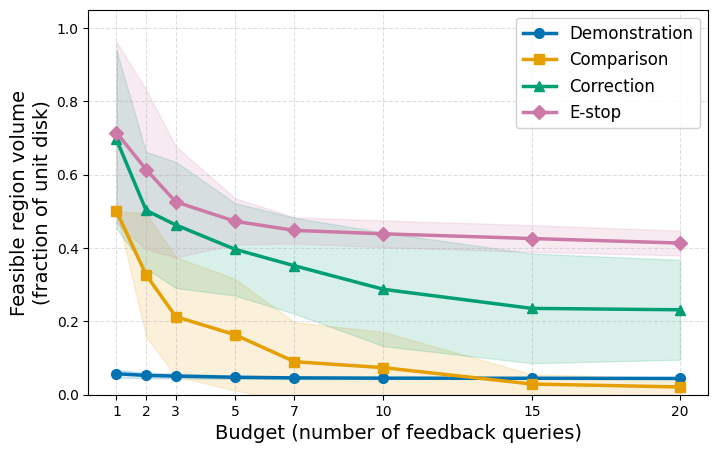

Saved: budget_sweep/volume_vs_budget.pdf


In [6]:
COLORS = {
    "Demonstration": "#0072B2",  # Okabe-Ito blue
    "Comparison":    "#E69F00",  # Okabe-Ito amber
    "Correction":    "#009E73",  # Okabe-Ito teal
    "E-stop":        "#CC79A7",  # Okabe-Ito mauve
}

MARKERS = {
    "Demonstration": "o",
    "Comparison":    "s",
    "Correction":    "^",
    "E-stop":        "D",
}

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODALITIES:
    vols  = np.array(results[name])           # (num_budgets, num_trials)
    means = vols.mean(axis=1)
    stds  = vols.std(axis=1)
    color = COLORS[name]

    ax.plot(BUDGETS, means,
            marker=MARKERS[name], linewidth=2.5, markersize=7,
            color=color, label=name)
    ax.fill_between(BUDGETS,
                    means - stds, means + stds,
                    alpha=0.15, color=color)

ax.set_xlabel("Budget (number of feedback queries)", fontsize=14)
ax.set_ylabel("Feasible region volume\n(fraction of unit disk)", fontsize=14)
#ax.set_title("Reward ambiguity vs. feedback budget", fontsize=15)
ax.set_xticks(BUDGETS)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4)

os.makedirs("budget_sweep", exist_ok=True)
fig.savefig("budget_sweep/volume_vs_budget.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: budget_sweep/volume_vs_budget.pdf")

## Supplementary: log-scale x-axis (easier to read for small budgets)

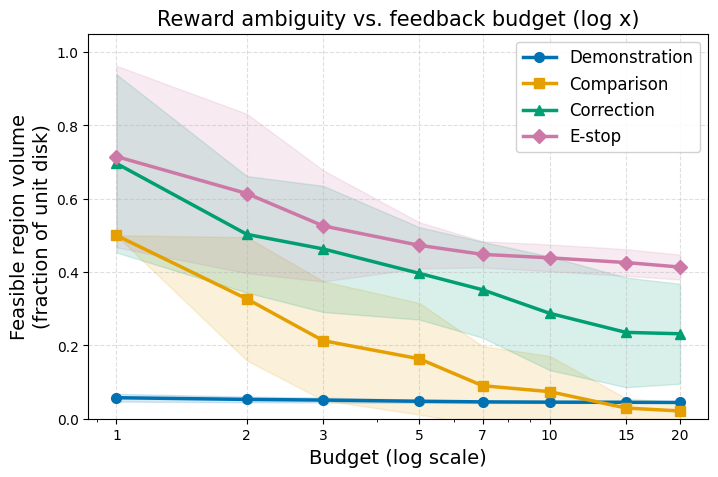

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

for name in MODALITIES:
    vols  = np.array(results[name])
    means = vols.mean(axis=1)
    stds  = vols.std(axis=1)
    color = COLORS[name]

    ax.plot(BUDGETS, means,
            marker=MARKERS[name], linewidth=2.5, markersize=7,
            color=color, label=name)
    ax.fill_between(BUDGETS,
                    means - stds, means + stds,
                    alpha=0.15, color=color)

ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(BUDGETS)
ax.set_xlabel("Budget (log scale)", fontsize=14)
ax.set_ylabel("Feasible region volume\n(fraction of unit disk)", fontsize=14)
ax.set_title("Reward ambiguity vs. feedback budget (log x)", fontsize=15)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4)

fig.savefig("budget_sweep/volume_vs_budget_log.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Heatmaps at selected budgets

Reproduces the qualitative heatmap comparison from Figure 2 of the paper,
but now with **budget-matched** feedback (same B for all modalities) at
three representative budget levels.

  Building heatmap: B=1, Demonstration ...


  Building heatmap: B=1, Comparison ...
  Building heatmap: B=1, Correction ...


  Building heatmap: B=1, E-stop ...


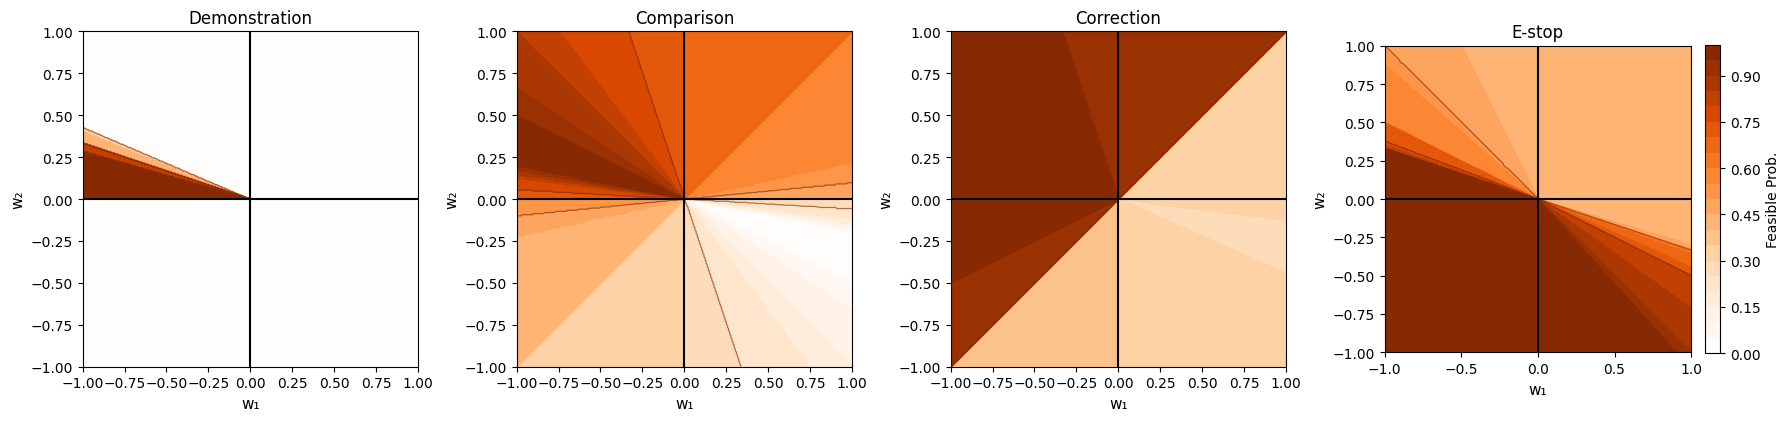

Saved: budget_sweep/heatmaps_budget_1.pdf
  Building heatmap: B=2, Demonstration ...


  Building heatmap: B=2, Comparison ...


  Building heatmap: B=2, Correction ...


  Building heatmap: B=2, E-stop ...


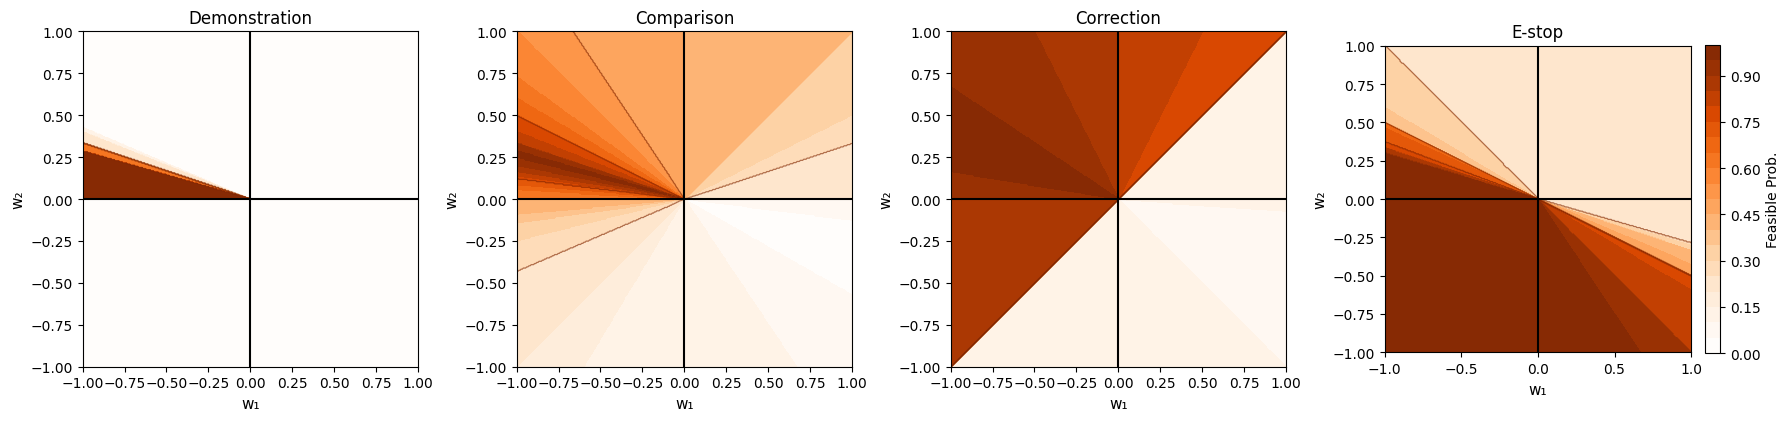

Saved: budget_sweep/heatmaps_budget_2.pdf
  Building heatmap: B=3, Demonstration ...


  Building heatmap: B=3, Comparison ...


  Building heatmap: B=3, Correction ...


  Building heatmap: B=3, E-stop ...


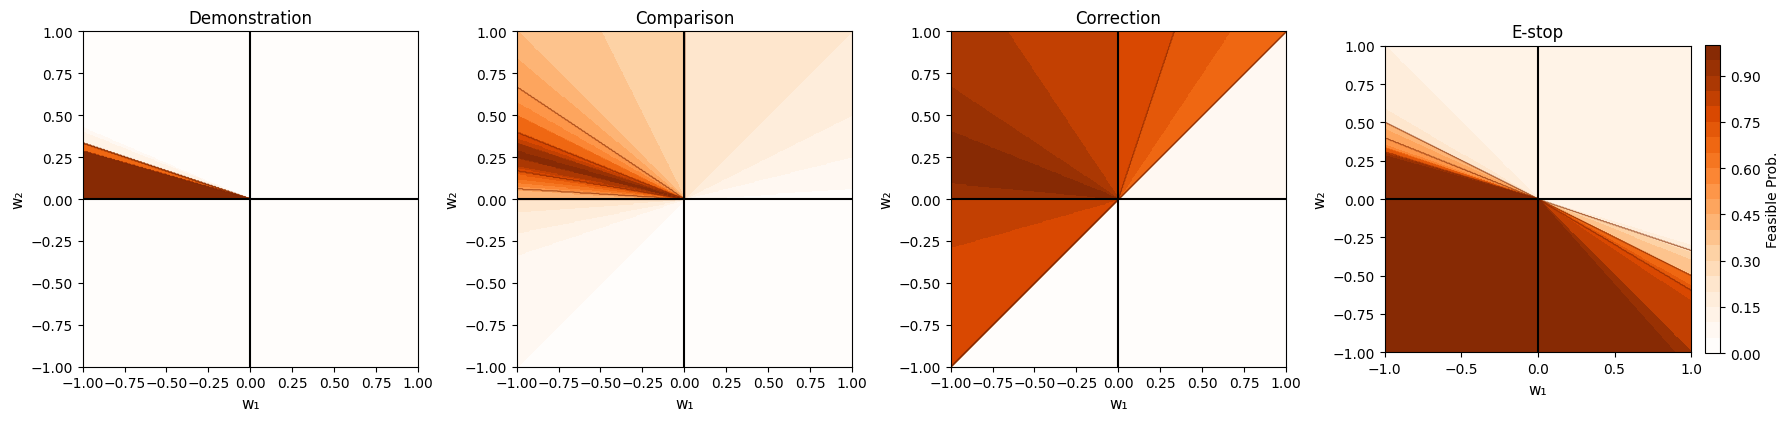

Saved: budget_sweep/heatmaps_budget_3.pdf
  Building heatmap: B=5, Demonstration ...


  Building heatmap: B=5, Comparison ...


  Building heatmap: B=5, Correction ...


  Building heatmap: B=5, E-stop ...


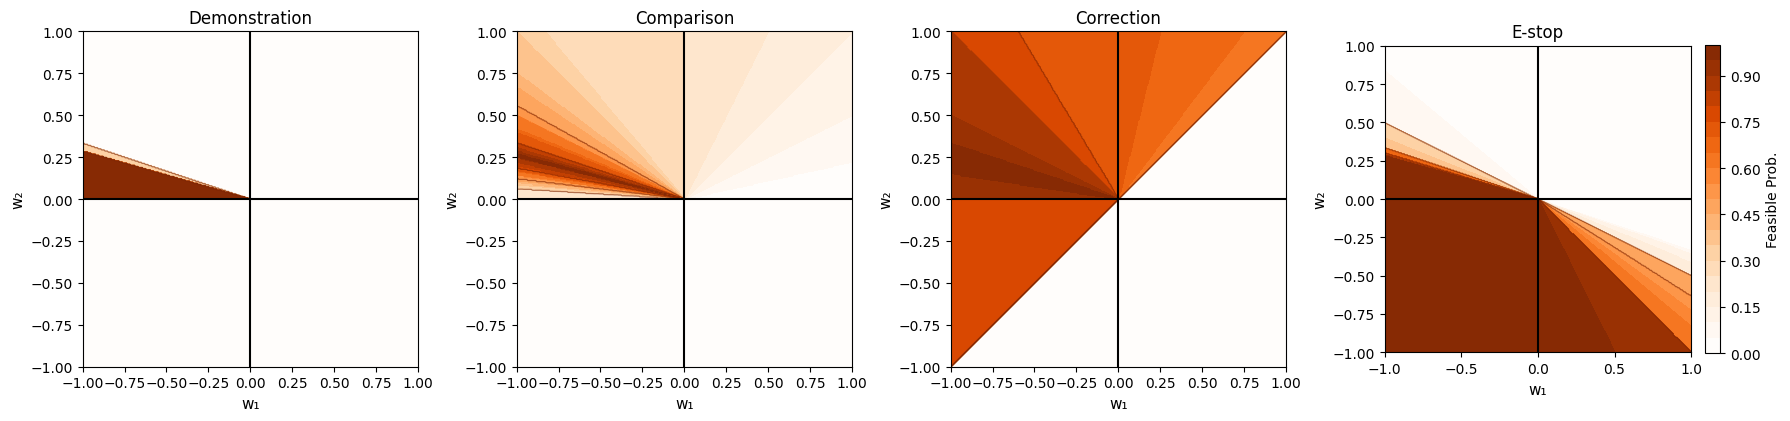

Saved: budget_sweep/heatmaps_budget_5.pdf
  Building heatmap: B=7, Demonstration ...


  Building heatmap: B=7, Comparison ...


  Building heatmap: B=7, Correction ...


  Building heatmap: B=7, E-stop ...


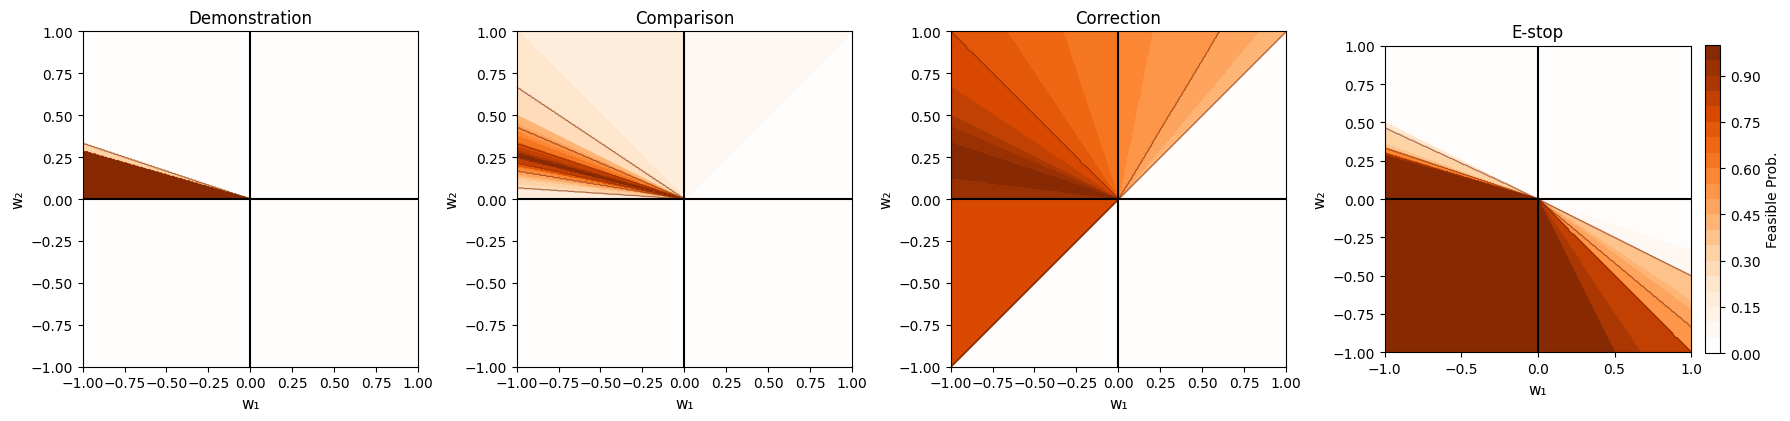

Saved: budget_sweep/heatmaps_budget_7.pdf
  Building heatmap: B=10, Demonstration ...


  Building heatmap: B=10, Comparison ...


  Building heatmap: B=10, Correction ...


  Building heatmap: B=10, E-stop ...


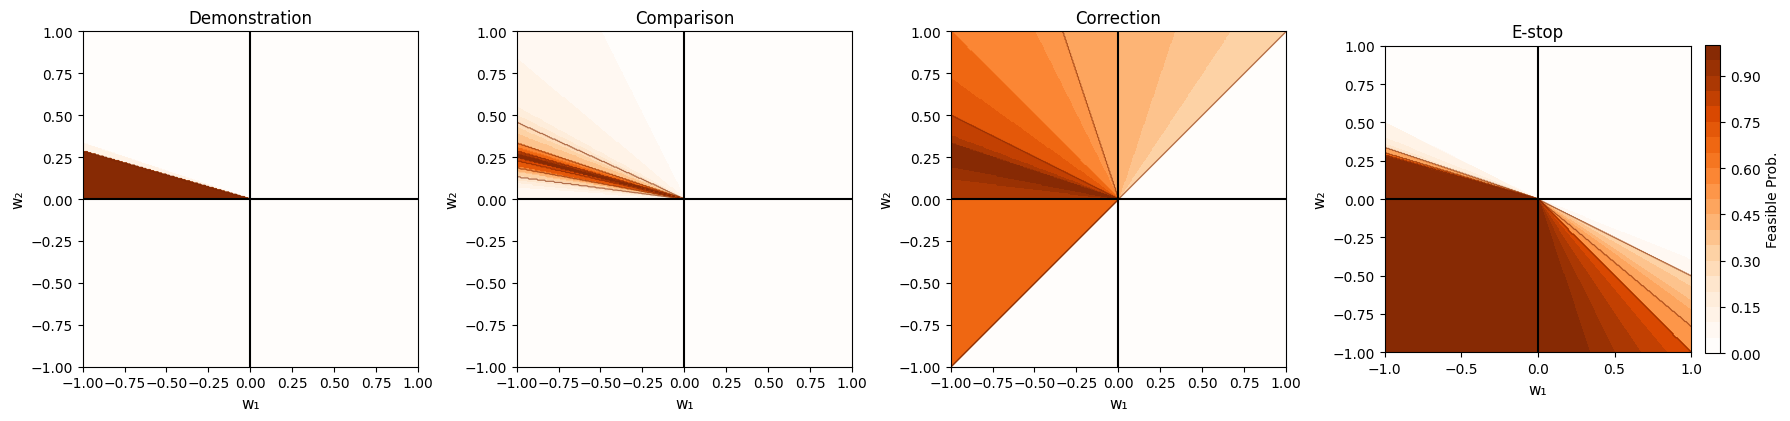

Saved: budget_sweep/heatmaps_budget_10.pdf
  Building heatmap: B=15, Demonstration ...


  Building heatmap: B=15, Comparison ...


  Building heatmap: B=15, Correction ...


  Building heatmap: B=15, E-stop ...


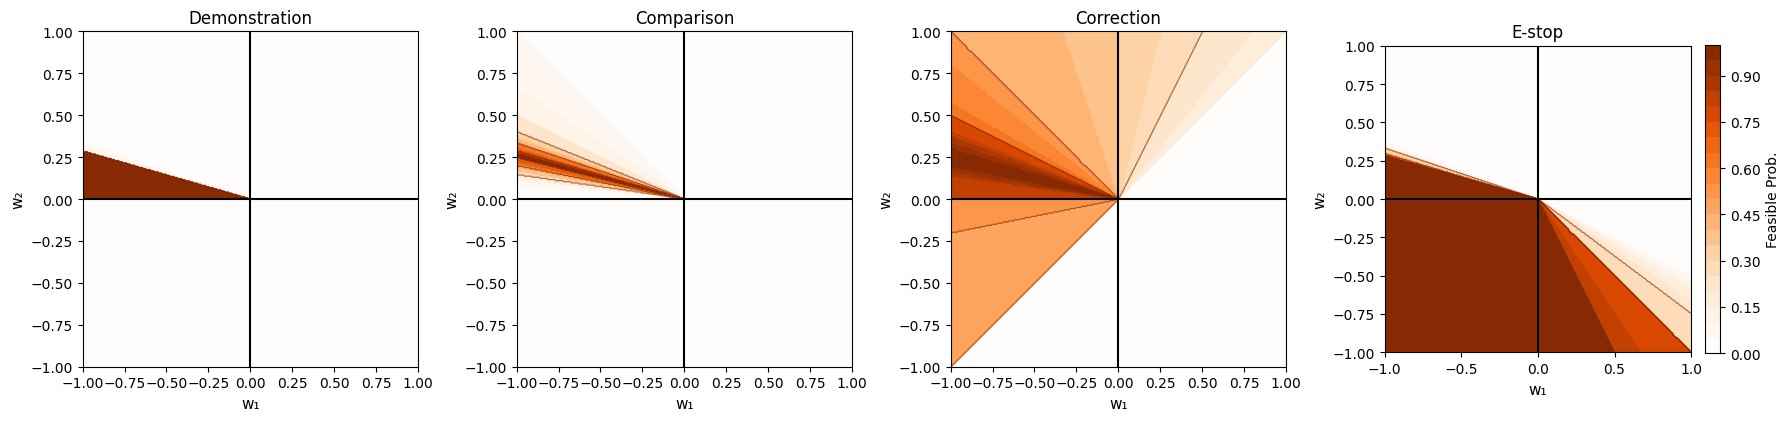

Saved: budget_sweep/heatmaps_budget_15.pdf
  Building heatmap: B=20, Demonstration ...


  Building heatmap: B=20, Comparison ...


  Building heatmap: B=20, Correction ...


  Building heatmap: B=20, E-stop ...


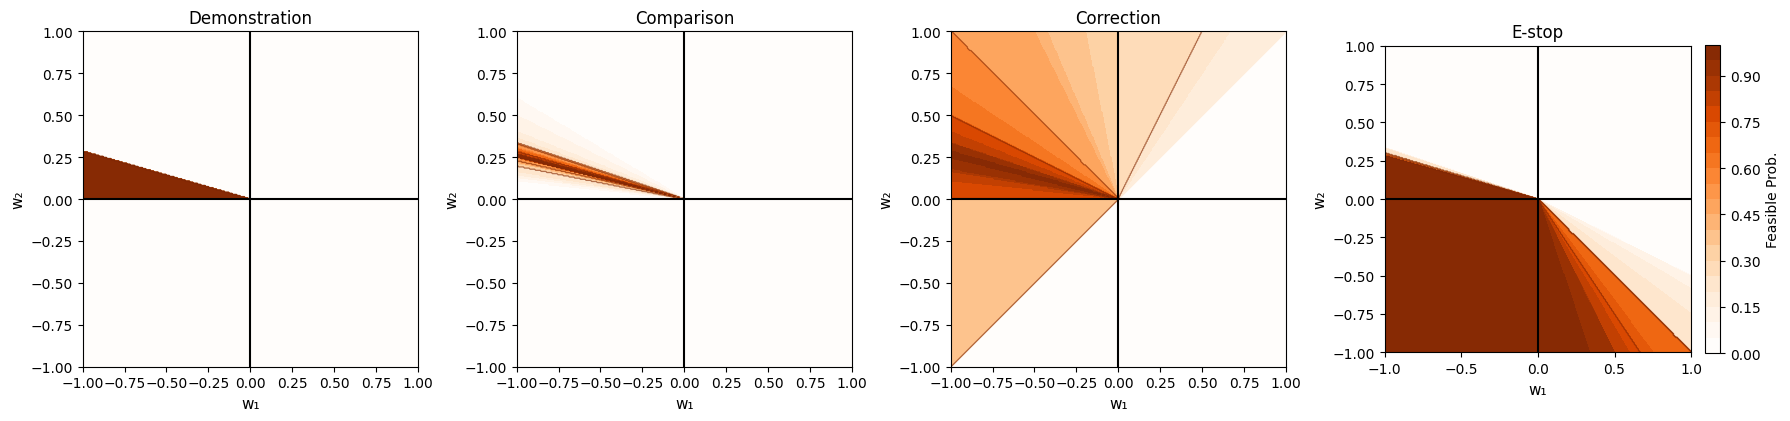

Saved: budget_sweep/heatmaps_budget_20.pdf


In [8]:
HEATMAP_BUDGETS = [1, 2, 3, 5, 7, 10, 15, 20]    # the three budget levels to visualize
HEATMAP_TRIALS  = 100           # trials for the heatmap accumulator
HEATMAP_RES     = 300

orange_cmap = LinearSegmentedColormap.from_list(
    "rich_orange",
    ["#ffffff","#fff5eb","#fee6ce","#fdd0a2",
     "#fdae6b","#fd8d3c","#f16913","#d94801",
     "#a63603","#7f2704"],
    N=256,
)

x1h, x2h = np.meshgrid(
    np.linspace(-1, 1, HEATMAP_RES),
    np.linspace(-1, 1, HEATMAP_RES),
)


def build_heatmap(fn, budget, n_trials):
    """Accumulate feasibility across `n_trials` random samples."""
    acc = np.zeros_like(x1h, dtype=float)
    for _ in range(n_trials):
        constraints = fn(budget)
        feasible = np.ones_like(x1h, dtype=bool)
        for v in constraints:
            v = np.asarray(v, float)
            if v.size < 2 or np.allclose(v, 0):
                continue
            feasible &= (v[0]*x1h + v[1]*x2h >= 0)
        acc += feasible.astype(float)
    return acc / n_trials


modal_names = list(MODALITIES.keys())

for B in HEATMAP_BUDGETS:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    #fig.suptitle(f"Budget heatmaps  (B = {B} queries per modality)",
    #             fontsize=14, y=1.02)

    for ax, (name, fn) in zip(axes, MODALITIES.items()):
        print(f"  Building heatmap: B={B}, {name} ...")
        hmap = build_heatmap(fn, B, HEATMAP_TRIALS)

        cf = ax.contourf(x1h, x2h, hmap,
                         levels=np.linspace(0, 1, 21),
                         cmap=orange_cmap)
        ax.contour(x1h, x2h, hmap,
                   levels=[0.25, 0.5, 0.75],
                   colors="#7f2704", linewidths=0.9, alpha=0.6)

        # True reward marker
        # ax.scatter(TRUE_REWARD[0], TRUE_REWARD[1],
        #            color='black', s=120, marker='*', zorder=5)

        ax.axhline(0, color='black', linewidth=1.5)
        ax.axvline(0, color='black', linewidth=1.5)
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_aspect('equal')
        ax.set_title(name, fontsize=12)
        ax.set_xlabel('w₁', fontsize=11)
        ax.set_ylabel('w₂', fontsize=11)

        # Add colorbar only on the last subplot
        if name == modal_names[-1]:
            cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("Feasible Prob.", fontsize=10)

    plt.tight_layout()
    fname = f"budget_sweep/heatmaps_budget_{B}.pdf"
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

Building heatmap: Demonstration (B=5) ...


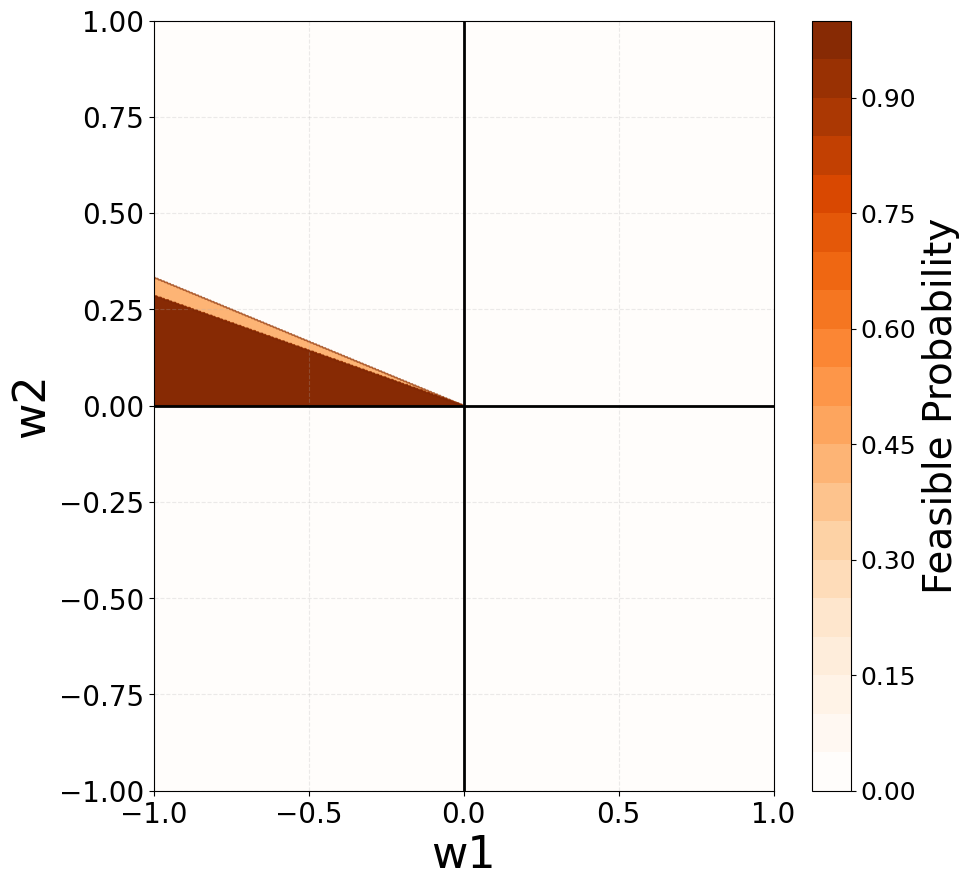

Saved: budget_sweep/demonstration_feasible_probability_heatmap.pdf
Building heatmap: Comparison (B=5) ...


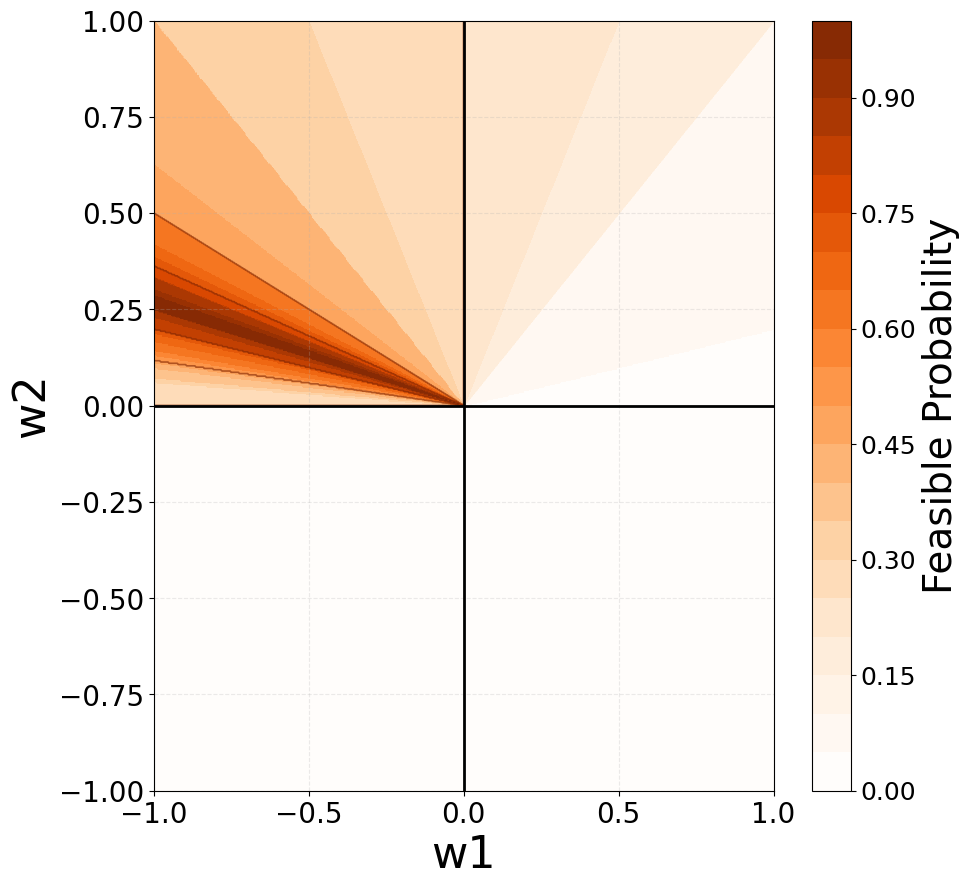

Saved: budget_sweep/comparison_feasible_probability_heatmap.pdf
Building heatmap: Correction (B=5) ...


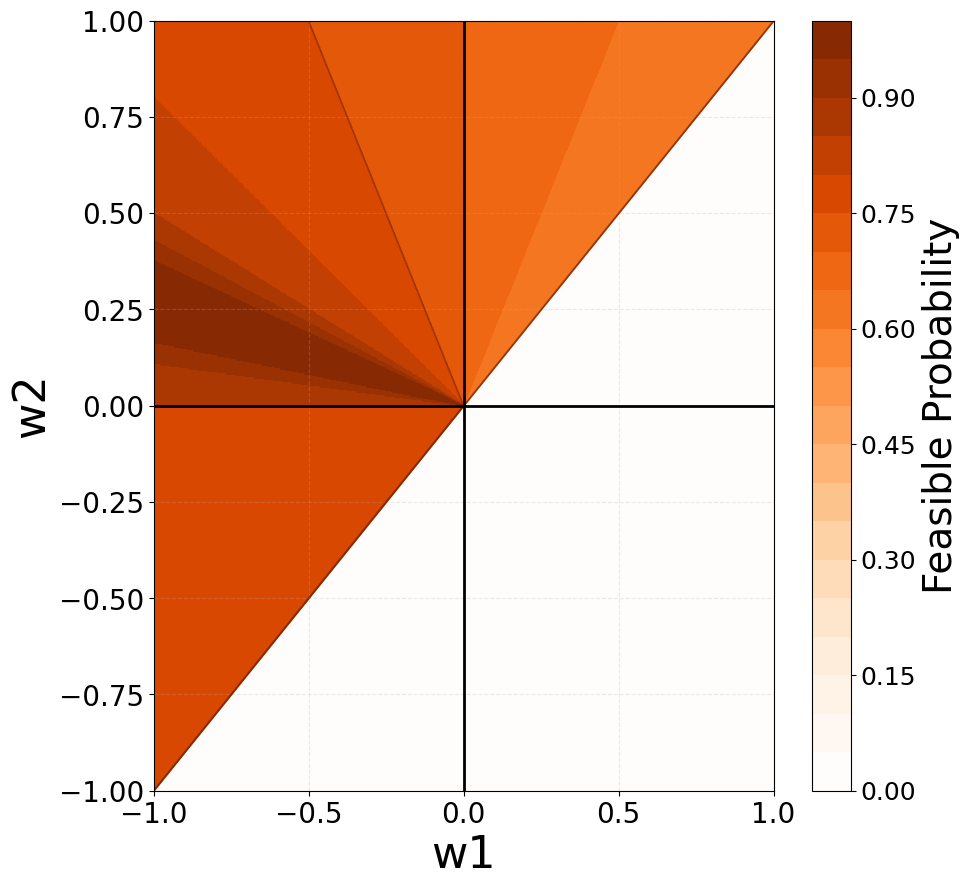

Saved: budget_sweep/correction_feasible_probability_heatmap.pdf
Building heatmap: E-stop (B=5) ...


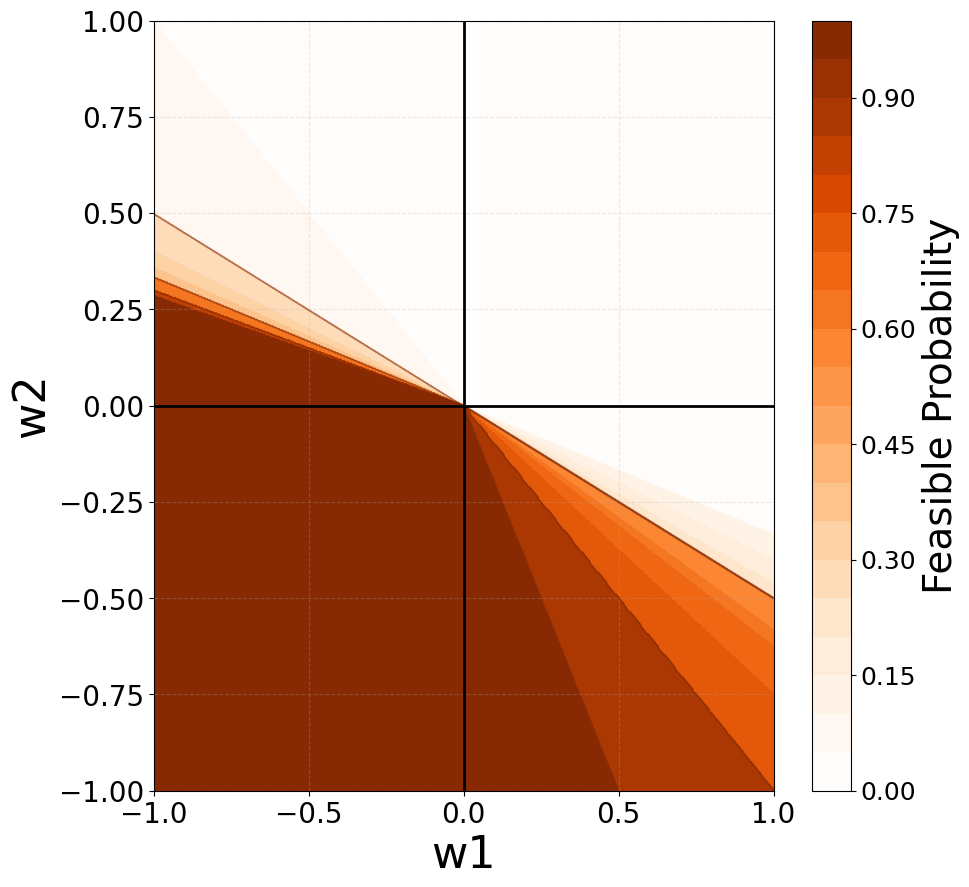

Saved: budget_sweep/estop_feasible_probability_heatmap.pdf


In [9]:
HEATMAP_BUDGET = 5
HEATMAP_TRIALS = 100
HEATMAP_RES    = 600

orange_cmap = LinearSegmentedColormap.from_list(
    "rich_orange",
    ["#ffffff","#fff5eb","#fee6ce","#fdd0a2",
     "#fdae6b","#fd8d3c","#f16913","#d94801",
     "#a63603","#7f2704"],
    N=256,
)

x1h, x2h = np.meshgrid(
    np.linspace(-1, 1, HEATMAP_RES),
    np.linspace(-1, 1, HEATMAP_RES),
)

FILE_NAMES = {
    "Demonstration": "demonstration_feasible_probability_heatmap.pdf",
    "Comparison":    "comparison_feasible_probability_heatmap.pdf",
    "Correction":    "correction_feasible_probability_heatmap.pdf",
    "E-stop":        "estop_feasible_probability_heatmap.pdf",
}


def build_heatmap(fn, budget, n_trials):
    acc = np.zeros_like(x1h, dtype=float)
    for _ in range(n_trials):
        constraints = fn(budget)
        feasible = np.ones_like(x1h, dtype=bool)
        for v in constraints:
            v = np.asarray(v, float)
            if v.size < 2 or np.allclose(v, 0):
                continue
            feasible &= (v[0]*x1h + v[1]*x2h >= 0)
        acc += feasible.astype(float)
    return acc / n_trials


os.makedirs("budget_sweep", exist_ok=True)

for name, fn in MODALITIES.items():
    print(f"Building heatmap: {name} (B={HEATMAP_BUDGET}) ...")
    hmap = build_heatmap(fn, HEATMAP_BUDGET, HEATMAP_TRIALS)

    plt.figure(figsize=(10, 10))
    plt.gca().set_facecolor("white")

    cf = plt.contourf(x1h, x2h, hmap,
                      levels=np.linspace(0, 1, 21),
                      cmap=orange_cmap)
    plt.contour(x1h, x2h, hmap,
                levels=[0.25, 0.5, 0.75],
                colors="#7f2704", linewidths=1.2, alpha=0.6)

    # plt.scatter(TRUE_REWARD[0], TRUE_REWARD[1],
    #             color='black', s=150, marker='*', zorder=5)

    plt.axhline(0, color='black', linewidth=2)
    plt.axvline(0, color='black', linewidth=2)
    plt.grid(True, linestyle="--", alpha=0.25)
    plt.xlabel('w1', fontsize=32)
    plt.ylabel('w2', fontsize=32)
    plt.tick_params(axis='both', labelsize=20)
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)

    cbar = plt.colorbar(cf)
    cbar.set_label("Feasible Probability", fontsize=28)
    cbar.ax.tick_params(labelsize=18)

    fname = f"budget_sweep/{FILE_NAMES[name]}"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

## Summary statistics table

In [10]:
import pandas as pd

rows = []
for name in MODALITIES:
    vols = np.array(results[name])   # (num_budgets, num_trials)
    for bi, B in enumerate(BUDGETS):
        v = vols[bi]
        rows.append({
            "Modality": name,
            "Budget": B,
            "Mean volume": round(v.mean(), 4),
            "Std": round(v.std(), 4),
            "Median": round(np.median(v), 4),
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

df.to_csv("budget_sweep/volume_statistics.csv", index=False)
print("\nSaved: budget_sweep/volume_statistics.csv")

     Modality  Budget  Mean volume    Std  Median
Demonstration       1       0.0573 0.0106  0.0517
Demonstration       2       0.0527 0.0078  0.0517
Demonstration       3       0.0509 0.0067  0.0517
Demonstration       5       0.0476 0.0043  0.0442
Demonstration       7       0.0459 0.0031  0.0442
Demonstration      10       0.0452 0.0025  0.0442
Demonstration      15       0.0449 0.0021  0.0442
Demonstration      20       0.0443 0.0007  0.0442
   Comparison       1       0.5000 0.0002  0.5000
   Comparison       2       0.3268 0.1681  0.3969
   Comparison       3       0.2129 0.1622  0.1673
   Comparison       5       0.1635 0.1523  0.0924
   Comparison       7       0.0901 0.1079  0.0447
   Comparison      10       0.0738 0.0974  0.0352
   Comparison      15       0.0292 0.0266  0.0245
   Comparison      20       0.0211 0.0233  0.0157
   Correction       1       0.6962 0.2429  0.5023
   Correction       2       0.5029 0.1590  0.5023
   Correction       3       0.4631 0.1721  0.5023


## Cross-over analysis

At what budget does each non-demonstration modality reach the same mean
volume as demonstrations at B = 3?  This quantifies how many more queries
are needed to match demonstration efficiency.

In [11]:
demo_means = np.array(results["Demonstration"]).mean(axis=1)   # (num_budgets,)

# Reference: demo volume at B=3
b3_idx      = BUDGETS.index(3)
demo_at_3   = demo_means[b3_idx]
print(f"Demonstration volume at B=3: {demo_at_3:.4f}\n")

for name in ["Comparison", "Correction", "E-stop"]:
    means = np.array(results[name]).mean(axis=1)
    # Find first budget where the modality's volume drops below demo_at_3
    crossover = next(
        (BUDGETS[i] for i, m in enumerate(means) if m <= demo_at_3),
        None
    )
    if crossover is not None:
        print(f"{name:15s} reaches demo B=3 efficiency at B={crossover}")
    else:
        print(f"{name:15s} does NOT reach demo B=3 efficiency within B<={BUDGETS[-1]}")

Demonstration volume at B=3: 0.0509

Comparison      reaches demo B=3 efficiency at B=15
Correction      does NOT reach demo B=3 efficiency within B<=20
E-stop          does NOT reach demo B=3 efficiency within B<=20
